In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
np.random.seed(42)
n = 10000
df = pd.DataFrame({
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
})

df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
0,1,58,Female,164,175,234,77
1,2,71,Female,176,70,244,93
2,3,48,Female,103,115,207,77
3,4,34,Male,123,157,201,99
4,5,62,Female,177,91,210,90


In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Blood_Pressure,0
Sugar_Level,0
Cholesterol,0
Heart_Rate,0


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Blood_Pressure  10000 non-null  int64 
 4   Sugar_Level     10000 non-null  int64 
 5   Cholesterol     10000 non-null  int64 
 6   Heart_Rate      10000 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 547.0+ KB


In [ ]:
df.describe()

,Patient_ID,Age,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,50.290400,129.668100,135.618200,224.568500,89.890900
std,2886.89568,17.588957,29.138093,37.843946,43.604943,17.483803
min,1.00000,20.000000,80.000000,70.000000,150.000000,60.000000
25%,2500.75000,35.000000,104.000000,103.000000,187.000000,75.000000
50%,5000.50000,50.000000,130.000000,136.000000,224.000000,90.000000
75%,7500.25000,66.000000,155.000000,169.000000,262.000000,105.000000
max,10000.00000,80.000000,180.000000,200.000000,300.000000,120.000000


In [ ]:
df.mean(numeric_only=True)

,0
Patient_ID,5000.5000
Age,50.2904
Blood_Pressure,129.6681
Sugar_Level,135.6182
Cholesterol,224.5685
Heart_Rate,89.8909


In [ ]:
df.median(numeric_only=True)

,0
Patient_ID,5000.5
Age,50.0
Blood_Pressure,130.0
Sugar_Level,136.0
Cholesterol,224.0
Heart_Rate,90.0


In [ ]:
df["Gender"].mode()

,Gender
0,Male


In [ ]:
df.std(numeric_only=True)

,0
Patient_ID,2886.895680
Age,17.588957
Blood_Pressure,29.138093
Sugar_Level,37.843946
Cholesterol,43.604943
Heart_Rate,17.483803


In [ ]:
def bp_category(bp):
    if bp < 120:
        return "Normal"
    elif bp < 140:
        return "Elevated"
    else:
        return "High"

df["BP_Status"] = df["Blood_Pressure"].apply(bp_category)
print(df["BP_Status"].value_counts())

BP_Status
High        4025
Normal      3989
Elevated    1986
Name: count, dtype: int64


In [ ]:
def sugar_category(s):
    if s < 100:
        return "Normal"
    elif s < 140:
        return "Pre-Diabetic"
    else:
        return "Diabetic"

df["Sugar_Status"] = df["Sugar_Level"].apply(sugar_category)
print(df["Sugar_Status"].value_counts())

Sugar_Status
Diabetic        4758
Pre-Diabetic    2984
Normal          2258
Name: count, dtype: int64


In [ ]:
def chol_category(c):
    if c < 200:
        return "Normal"
    elif c < 240:
        return "Borderline"
    else:
        return "High"

df["Chol_Status"] = df["Cholesterol"].apply(chol_category)
print(df["Chol_Status"].value_counts())

Chol_Status
High          3991
Normal        3321
Borderline    2688
Name: count, dtype: int64


In [ ]:
print("Average Heart Rate:", df["Heart_Rate"].mean())

Average Heart Rate: 89.8909


In [ ]:
def risk_score(row):
    score = 0

    if row["Blood_Pressure"] > 140:
        score += 1
    if row["Sugar_Level"] > 140:
        score += 1
    if row["Cholesterol"] > 240:
        score += 1
    if row["Heart_Rate"] > 100 or row["Heart_Rate"] < 60:
        score += 1

    return score


df["Risk_Score"] = df.apply(risk_score, axis=1)
def risk_level(score):
    if score == 0:
        return "Low"
    elif score <= 2:
        return "Medium"
    else:
        return "High"
df["Risk_Level"] = df["Risk_Score"].apply(risk_level)
print(df[["Risk_Score", "Risk_Level"]].head())

   Risk_Score Risk_Level
0           2     Medium
1           2     Medium
2           0        Low
3           1     Medium
4           1     Medium


In [ ]:

high_risk_patients = df[df["Risk_Level"] == "High"]
print(high_risk_patients.head())

    Patient_ID  Age  Gender  Blood_Pressure  Sugar_Level  Cholesterol  \
11          12   42  Female             154          179          278   
14          15   43    Male              92          192          256   
15          16   72    Male             150          155          282   
19          20   22  Female             144          150          287   
26          27   57    Male             169          168          300   

    Heart_Rate BP_Status Sugar_Status Chol_Status  Risk_Score Risk_Level  
11          62      High     Diabetic        High           3       High  
14         114    Normal     Diabetic        High           3       High  
15          69      High     Diabetic        High           3       High  
19          71      High     Diabetic        High           3       High  
26          90      High     Diabetic        High           3       High  


In [ ]:
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ["20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [ ]:
print(pd.crosstab(df["Age_Group"], df["BP_Status"]))

BP_Status  Elevated  High  Normal
Age_Group                        
20-30           311   637     618
30-40           339   682     638
40-50           319   696     635
50-60           337   630     669
60-70           321   627     688
70-80           338   690     672


In [ ]:
print(df.groupby("Gender")[["Blood_Pressure", "Sugar_Level", "Cholesterol", "Heart_Rate"]].mean())

        Blood_Pressure  Sugar_Level  Cholesterol  Heart_Rate
Gender                                                      
Female      129.397387   136.374271   224.673568   90.015678
Male        129.936119   134.869652   224.464478   89.767363


In [ ]:
print(df["Risk_Level"].value_counts())

Risk_Level
Medium    6935
High      1719
Low       1346
Name: count, dtype: int64


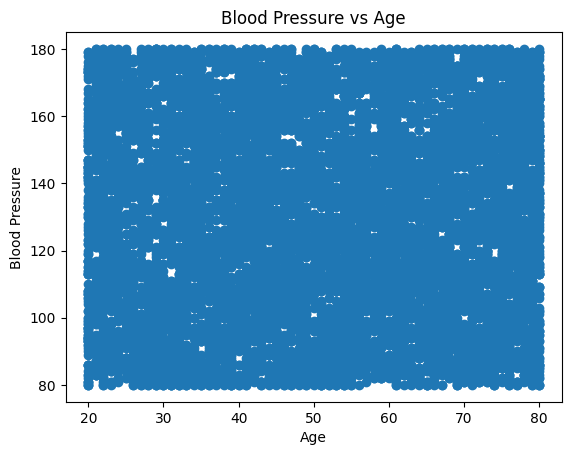

In [ ]:
plt.scatter(df["Age"], df["Blood_Pressure"])
plt.title("Blood Pressure vs Age")
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.show()

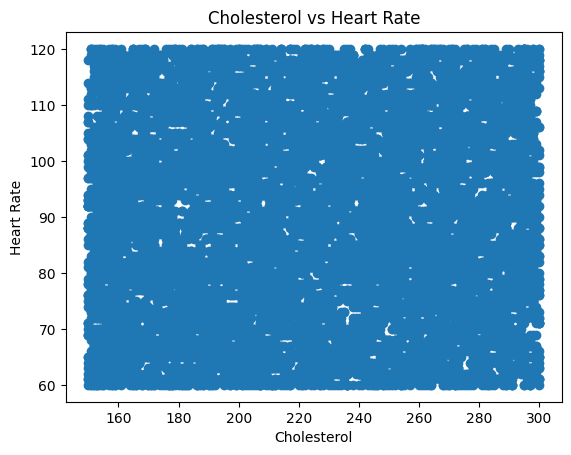

In [ ]:
plt.scatter(df["Cholesterol"], df["Heart_Rate"])
plt.title("Cholesterol vs Heart Rate")
plt.xlabel("Cholesterol")
plt.ylabel("Heart Rate")
plt.show()

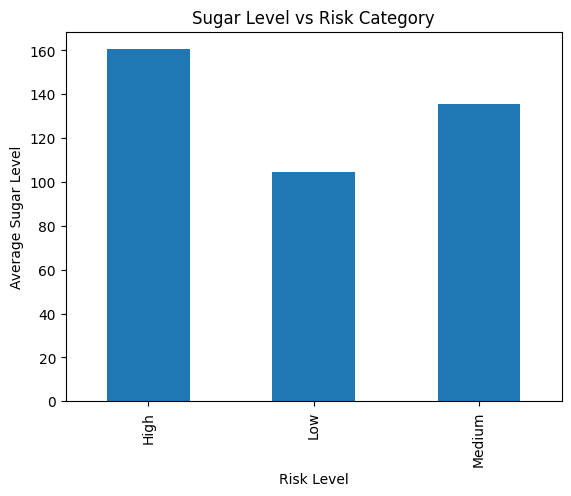

In [ ]:
df.groupby("Risk_Level")["Sugar_Level"].mean().plot(kind='bar')
plt.title("Sugar Level vs Risk Category")
plt.xlabel("Risk Level")
plt.ylabel("Average Sugar Level")
plt.show()

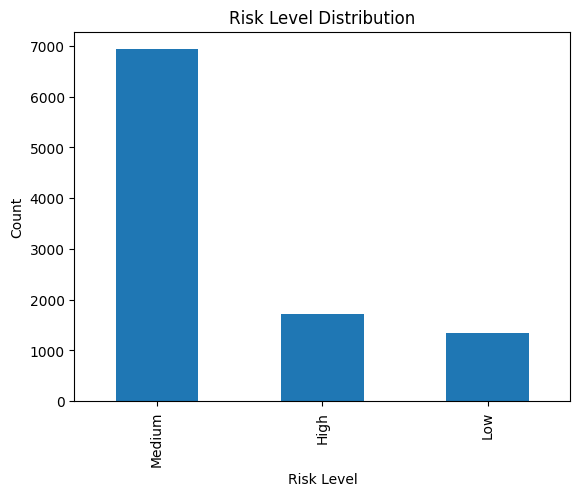

In [ ]:
df["Risk_Level"].value_counts().plot(kind='bar')
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

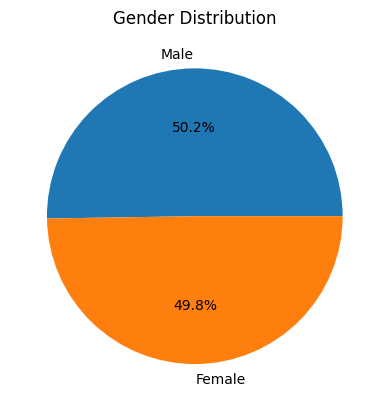

In [ ]:
df["Gender"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

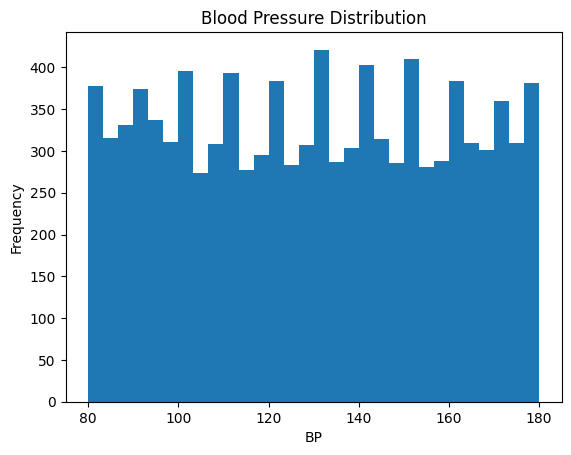

In [ ]:
plt.hist(df["Blood_Pressure"], bins=30)
plt.title("Blood Pressure Distribution")
plt.xlabel("BP")
plt.ylabel("Frequency")
plt.show()

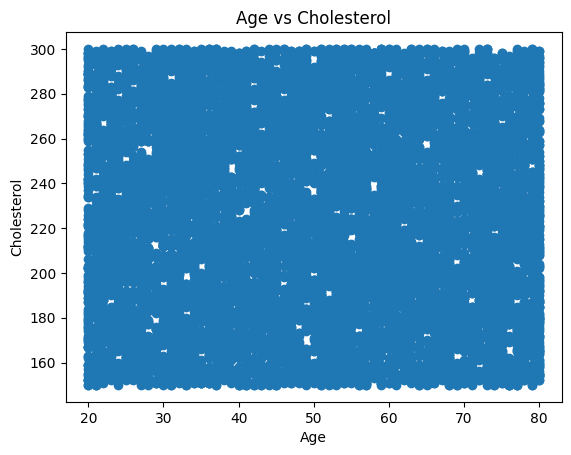

In [ ]:
plt.scatter(df["Age"], df["Cholesterol"])
plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

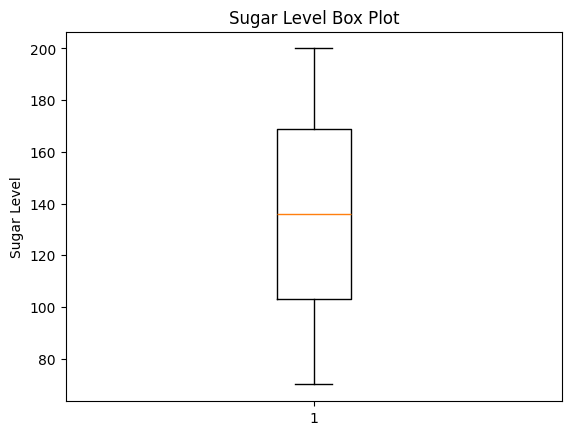

In [ ]:
plt.boxplot(df["Sugar_Level"])
plt.title("Sugar Level Box Plot")
plt.ylabel("Sugar Level")
plt.show()

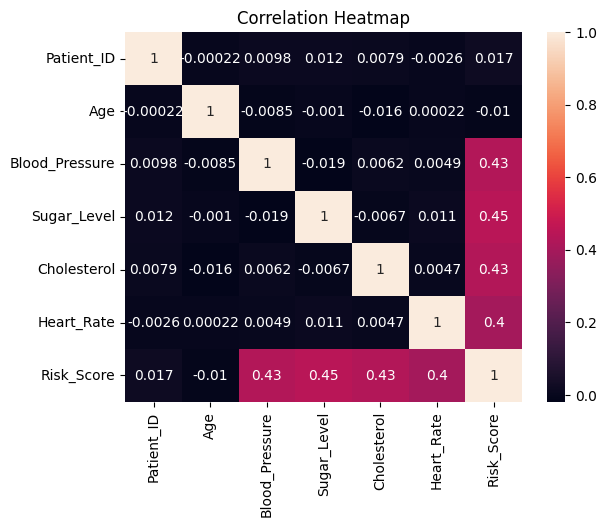

In [ ]:
import seaborn as sns

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

This project demonstrates how synthetic healthcare data can be analyzed using EDA techniques to identify patterns, relationships, and high-risk patients. Visualization tools such as heatmaps, histograms, and scatter plots help in understanding the data effectively. The system supports early detection of health risks, improves patient monitoring, and enables better healthcare decision-making.